# Rice Import Supplier Concentration: 100% Stacked Bar (2024)

Notebook ini mengolah data impor beras **HS 1006** berdasarkan **net weight (kg)** untuk empat negara: Filipina, Malaysia, Brunei Darussalam, dan Singapura.

Urutan analisisnya adalah:

1. membaca dan memvalidasi data UN Comtrade;
2. memisahkan baris `World` dari data negara pemasok;
3. membandingkan jumlah seluruh partner dengan total `World`;
4. menghitung supplier share dan HHI dari **seluruh pemasok asli**;
5. menggabungkan pemasok kecil menjadi `Other` hanya untuk visual;
6. membuat dan mengekspor grafik 100% stacked bar.

> Penting: HHI dihitung sebelum pemasok kecil digabung menjadi `Other`.

## 1. Impor library dan pengaturan tampilan

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "figure.dpi": 120
})

## 2. Konfigurasi file dan parameter visual

Notebook akan mencari CSV di folder yang sama, folder `upload`, atau `/content` jika dijalankan di Google Colab. Ubah `DATA_PATH` secara manual jika file disimpan di lokasi lain.

In [2]:
DATA_FILENAME = "TradeData_8_27_2026_21_50_21.csv"

candidate_paths = [
    Path(DATA_FILENAME),
    Path("upload") / DATA_FILENAME,
    Path("/content") / DATA_FILENAME,
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        f"File {DATA_FILENAME!r} tidak ditemukan. Letakkan CSV di folder yang sama "
        "dengan notebook atau ubah variabel DATA_PATH."
    )

OUTPUT_DIR = Path("output_stacked_bar")
OUTPUT_DIR.mkdir(exist_ok=True)

SELECTED_REPORTERS = [
    "Philippines",
    "Malaysia",
    "Brunei Darussalam",
    "Singapore",
]

MIN_SHARE_TO_KEEP = 0.03   # pemasok dipertahankan jika mencapai 3% di minimal satu negara
MIN_LABEL_PCT = 5          # label hanya tampil pada segmen minimal 5%

print("CSV ditemukan di:", DATA_PATH.resolve())

CSV ditemukan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\TradeData_8_27_2026_21_50_21.csv


## 3. Membaca data

CSV yang diberikan memiliki satu delimiter kosong tambahan pada akhir setiap baris. Karena itu, `index_col=False` sengaja digunakan agar kolom tidak bergeser saat dibaca oleh pandas.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.ParserWarning)
    raw = pd.read_csv(DATA_PATH, index_col=False)

print(f"Jumlah baris: {len(raw):,}")
print(f"Jumlah kolom: {raw.shape[1]:,}")
display(raw.head())

Jumlah baris: 69
Jumlah kolom: 47


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,0,W00,World,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"31,285,681.0000",False,8,kg,"31,285,681.0000",False,"31,285,681.0000",False,0.0000,False,"33,866,348.1290",NaN,"33,866,348.1290",0,False,True
1,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,36,AUS,Australia,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"119,120.0000",False,8,kg,"119,120.0000",False,"119,120.0000",False,0.0000,False,"171,562.9230",NaN,"171,562.9230",0,False,True
2,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,50,BGD,Bangladesh,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"3,000.0000",False,8,kg,"3,000.0000",False,"3,000.0000",False,0.0000,False,"4,764.3890",NaN,"4,764.3890",0,False,True
3,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,116,KHM,Cambodia,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"9,009,000.0000",False,8,kg,"9,009,000.0000",False,"9,009,000.0000",False,0.0000,False,"8,785,176.6490",NaN,"8,785,176.6490",0,False,True
4,C,A,20240101,2024,52,2024,96,BRN,Brunei Darussalam,M,Import,156,CHN,China,0,W00,World,H6,HS,True,1006,Rice,4,False,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,"13,400.0000",False,8,kg,"13,400.0000",False,"13,400.0000",False,0.0000,False,"98,001.2030",NaN,"98,001.2030",0,False,True


## 4. Validasi struktur dan cakupan data

Pemeriksaan ini memastikan bahwa perhitungan menggunakan impor HS 1006 tahun 2024, satuan kilogram, dan empat reporter yang dipilih.

In [4]:
required_columns = {
    "refYear", "reporterCode", "reporterDesc", "flowDesc",
    "partnerCode", "partnerDesc", "classificationCode",
    "cmdCode", "cmdDesc", "qtyUnitAbbr", "netWgt",
    "isNetWgtEstimated"
}
missing_columns = required_columns.difference(raw.columns)
assert not missing_columns, f"Kolom wajib tidak ditemukan: {sorted(missing_columns)}"

raw["refYear"] = pd.to_numeric(raw["refYear"], errors="coerce")
raw["cmdCode"] = pd.to_numeric(raw["cmdCode"], errors="coerce")
raw["partnerCode"] = pd.to_numeric(raw["partnerCode"], errors="coerce")
raw["netWgt"] = pd.to_numeric(raw["netWgt"], errors="coerce")

assert set(raw["refYear"].dropna().astype(int)) == {2024}, "Data harus hanya memuat tahun 2024."
assert set(raw["flowDesc"].dropna()) == {"Import"}, "Flow harus hanya Import."
assert set(raw["cmdCode"].dropna().astype(int)) == {1006}, "Commodity harus HS 1006."
assert set(raw["qtyUnitAbbr"].dropna()) == {"kg"}, "Net weight harus menggunakan kg."

actual_reporters = set(raw["reporterDesc"].dropna())
missing_reporters = set(SELECTED_REPORTERS).difference(actual_reporters)
assert not missing_reporters, f"Reporter tidak ditemukan: {sorted(missing_reporters)}"

validation_summary = pd.DataFrame({
    "Pemeriksaan": [
        "Tahun", "Flow", "HS code", "Commodity",
        "Classification", "Satuan", "Reporter"
    ],
    "Nilai": [
        sorted(raw["refYear"].dropna().astype(int).unique().tolist()),
        sorted(raw["flowDesc"].dropna().unique().tolist()),
        sorted(raw["cmdCode"].dropna().astype(int).unique().tolist()),
        sorted(raw["cmdDesc"].dropna().unique().tolist()),
        sorted(raw["classificationCode"].dropna().unique().tolist()),
        sorted(raw["qtyUnitAbbr"].dropna().unique().tolist()),
        sorted(actual_reporters),
    ]
})
display(validation_summary)

,Pemeriksaan,Nilai
0,Tahun,[2024]
1,Flow,[Import]
2,HS code,[1006]
3,Commodity,[Rice]
4,Classification,[H6]
5,Satuan,[kg]
6,Reporter,"[Brunei Darussalam, Malaysia, Philippines, Sin..."


## 5. Memisahkan `World` dan data pemasok

Baris `World` adalah total pembanding. Baris ini tidak boleh diperlakukan sebagai pemasok dan tidak masuk ke supplier share maupun HHI. Jika pasangan reporter–partner muncul lebih dari sekali, net weight dijumlahkan terlebih dahulu.

In [5]:
data = raw.loc[raw["reporterDesc"].isin(SELECTED_REPORTERS)].copy()

world_rows = data.loc[data["partnerCode"].eq(0)].copy()
world_row_count = (
    world_rows.groupby("reporterDesc")
    .size()
    .reindex(SELECTED_REPORTERS, fill_value=0)
)
assert world_row_count.eq(1).all(), (
    "Setiap reporter seharusnya memiliki tepat satu baris World. "
    f"Ditemukan: {world_row_count.to_dict()}"
)

world = (
    world_rows.groupby("reporterDesc", as_index=False)
    .agg(world_netWgt=("netWgt", "sum"))
)

partner_rows = data.loc[
    data["partnerCode"].ne(0)
    & data["netWgt"].notna()
    & data["netWgt"].gt(0)
].copy()

def any_estimated(series):
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"}).any()

partners = (
    partner_rows.groupby(["reporterDesc", "partnerDesc"], as_index=False)
    .agg(
        netWgt=("netWgt", "sum"),
        estimated=("isNetWgtEstimated", any_estimated),
    )
)

print(f"Baris World: {len(world_rows):,}")
print(f"Kombinasi reporter-pemasok setelah agregasi: {len(partners):,}")
display(partners.head())

Baris World: 4
Kombinasi reporter-pemasok setelah agregasi: 65


,reporterDesc,partnerDesc,netWgt,estimated
0,Brunei Darussalam,Australia,"119,120.0000",False
1,Brunei Darussalam,Bangladesh,"3,000.0000",False
2,Brunei Darussalam,Cambodia,"9,009,000.0000",False
3,Brunei Darussalam,China,"13,400.0000",False
4,Brunei Darussalam,India,"2,337,221.0000",False


## 6. Quality check terhadap total `World`

Rumus gap yang digunakan adalah:

$$
Gap_i = \frac{\left|\sum_j Weight_{ij} - WorldTotal_i\right|}{WorldTotal_i} \times 100
$$

Gap yang mendekati 0% menunjukkan bahwa total seluruh partner konsisten dengan total `World`.

In [6]:
partner_total = (
    partners.groupby("reporterDesc", as_index=False)
    .agg(
        partner_sum_kg=("netWgt", "sum"),
        supplier_count=("partnerDesc", "nunique"),
        estimated_supplier_rows=("estimated", "sum"),
    )
)

quality_check = world.merge(partner_total, on="reporterDesc", how="outer")
quality_check["gap_kg"] = (
    quality_check["partner_sum_kg"] - quality_check["world_netWgt"]
).abs()
quality_check["gap_pct"] = (
    quality_check["gap_kg"] / quality_check["world_netWgt"] * 100
)
quality_check["world_tonnes"] = quality_check["world_netWgt"] / 1_000
quality_check["partner_sum_tonnes"] = quality_check["partner_sum_kg"] / 1_000

quality_check = quality_check.set_index("reporterDesc").reindex(SELECTED_REPORTERS).reset_index()
display(quality_check[[
    "reporterDesc", "world_tonnes", "partner_sum_tonnes",
    "gap_pct", "supplier_count", "estimated_supplier_rows"
]])

if quality_check["gap_pct"].max() > 0.5:
    print("PERINGATAN: ada gap lebih dari 0,5%. Periksa data kosong, partner rahasia, atau duplikasi.")
else:
    print("Quality check lulus: seluruh gap berada di bawah atau sama dengan 0,5%.")

,reporterDesc,world_tonnes,partner_sum_tonnes,gap_pct,supplier_count,estimated_supplier_rows
0,Philippines,"4,770,088.6506","4,770,088.6506",0.0000,14,0
1,Malaysia,"1,695,309.6829","1,695,309.6829",0.0000,13,0
2,Brunei Darussalam,"31,285.6810","31,285.6810",0.0000,12,0
3,Singapore,"448,503.0800","448,503.0800",0.0000,26,0


Quality check lulus: seluruh gap berada di bawah atau sama dengan 0,5%.


## 7. Menghitung supplier share

Untuk importir $i$ dan pemasok $j$:

$$
SupplierShare_{ij} = \frac{NetWeight_{ij}}{\sum_j NetWeight_{ij}}
$$

Perhitungan menggunakan angka penuh. Pembulatan hanya dilakukan saat hasil ditampilkan.

In [7]:
partners["total_import_kg"] = (
    partners.groupby("reporterDesc")["netWgt"].transform("sum")
)
partners["share"] = partners["netWgt"] / partners["total_import_kg"]
partners["share_pct"] = partners["share"] * 100
partners["import_tonnes"] = partners["netWgt"] / 1_000

share_check = partners.groupby("reporterDesc")["share_pct"].sum()
assert np.allclose(share_check.to_numpy(), 100, atol=1e-8), "Supplier share tidak berjumlah 100%."

supplier_share_table = partners.sort_values(
    ["reporterDesc", "share_pct"], ascending=[True, False]
)[[
    "reporterDesc", "partnerDesc", "netWgt", "import_tonnes",
    "share", "share_pct", "estimated"
]]

display(supplier_share_table.groupby("reporterDesc", group_keys=False).head(6))

,reporterDesc,partnerDesc,netWgt,import_tonnes,share,share_pct,estimated
10,Brunei Darussalam,Thailand,"19,496,770.0000","19,496.7700",0.6232,62.3185,False
2,Brunei Darussalam,Cambodia,"9,009,000.0000","9,009.0000",0.2880,28.7959,False
4,Brunei Darussalam,India,"2,337,221.0000","2,337.2210",0.0747,7.4706,False
11,Brunei Darussalam,Viet Nam,"149,130.0000",149.1300,0.0048,0.4767,False
0,Brunei Darussalam,Australia,"119,120.0000",119.1200,0.0038,0.3807,False
7,Brunei Darussalam,"Other Asia, nes","64,470.0000",64.4700,0.0021,0.2061,False
24,Malaysia,Viet Nam,"687,637,318.0000","687,637.3180",0.4056,40.5612,False
20,Malaysia,Pakistan,"382,051,200.0000","382,051.2000",0.2254,22.5358,False
15,Malaysia,India,"325,761,990.0000","325,761.9900",0.1922,19.2155,False
23,Malaysia,Thailand,"217,821,480.0000","217,821.4800",0.1285,12.8485,False


## 8. Menghitung HHI dari seluruh pemasok asli

HHI menjumlahkan kuadrat seluruh supplier share:

$$
HHI_i = \sum_j s_{ij}^{2}
$$

Nilai desimal dikalikan 10.000 agar hasil berada pada skala 0 sampai 10.000. Batas interpretasi di notebook ini digunakan secara deskriptif untuk membandingkan struktur pemasok, bukan sebagai batas resmi kerentanan pangan.

In [8]:
partners["share_squared"] = partners["share"] ** 2

hhi_summary = (
    partners.groupby("reporterDesc", as_index=False)
    .agg(
        HHI=("share_squared", "sum"),
        supplier_count=("partnerDesc", "nunique"),
        import_kg=("netWgt", "sum"),
    )
)
hhi_summary["HHI_10000"] = hhi_summary["HHI"] * 10_000
hhi_summary["effective_suppliers"] = 1 / hhi_summary["HHI"]
hhi_summary["import_tonnes"] = hhi_summary["import_kg"] / 1_000

def interpret_hhi(value):
    if value < 1_000:
        return "Low concentration"
    if value <= 1_800:
        return "Moderate concentration"
    return "High concentration"

hhi_summary["interpretation"] = hhi_summary["HHI_10000"].apply(interpret_hhi)

top_supplier = (
    partners.loc[partners.groupby("reporterDesc")["share"].idxmax(),
                 ["reporterDesc", "partnerDesc", "share_pct"]]
    .rename(columns={
        "partnerDesc": "top_supplier",
        "share_pct": "top_supplier_share_pct",
    })
)
hhi_summary = hhi_summary.merge(top_supplier, on="reporterDesc", how="left")
hhi_summary = hhi_summary.sort_values("HHI_10000", ascending=False).reset_index(drop=True)

display(hhi_summary[[
    "reporterDesc", "top_supplier", "top_supplier_share_pct",
    "HHI_10000", "interpretation", "effective_suppliers",
    "supplier_count", "import_tonnes"
]])

,reporterDesc,top_supplier,top_supplier_share_pct,HHI_10000,interpretation,effective_suppliers,supplier_count,import_tonnes
0,Philippines,Viet Nam,74.4229,"5,781.7023",High concentration,1.7296,14,"4,770,088.6506"
1,Brunei Darussalam,Thailand,62.3185,"4,769.0670",High concentration,2.0968,12,"31,285.6810"
2,Singapore,India,35.2622,"2,912.2285",High concentration,3.4338,26,"448,503.0800"
3,Malaysia,Viet Nam,40.5612,"2,703.7000",High concentration,3.6986,13,"1,695,309.6829"


## 9. Memeriksa hasil utama

Nilai di bawah adalah hasil acuan dari file CSV yang diberikan. Toleransi kecil digunakan untuk mengantisipasi perbedaan presisi angka.

In [9]:
expected_hhi = {
    "Philippines": 5781.70,
    "Brunei Darussalam": 4769.07,
    "Singapore": 2912.23,
    "Malaysia": 2703.70,
}

actual_hhi = hhi_summary.set_index("reporterDesc")["HHI_10000"].to_dict()
for country, expected in expected_hhi.items():
    assert np.isclose(actual_hhi[country], expected, atol=0.10), (
        f"HHI {country} berbeda dari acuan: {actual_hhi[country]:.2f} vs {expected:.2f}"
    )

print("Pemeriksaan hasil lulus. HHI sesuai dengan data acuan.")

Pemeriksaan hasil lulus. HHI sesuai dengan data acuan.


## 10. Mengelompokkan pemasok kecil untuk visual

Pemasok dipertahankan sebagai kategori tersendiri jika share-nya mencapai minimal 3% di sedikitnya satu negara. Pemasok lain digabung menjadi `Other`. Langkah ini hanya mengubah tampilan grafik, bukan perhitungan HHI.

In [10]:
max_share_by_supplier = partners.groupby("partnerDesc")["share"].max()
major_suppliers = max_share_by_supplier[max_share_by_supplier >= MIN_SHARE_TO_KEEP].index

partners["supplier_plot"] = np.where(
    partners["partnerDesc"].isin(major_suppliers),
    partners["partnerDesc"],
    "Other",
)

plot_long = (
    partners.groupby(["reporterDesc", "supplier_plot"], as_index=False)
    .agg(share_pct=("share_pct", "sum"))
)

plot_data = (
    plot_long.pivot(
        index="reporterDesc", columns="supplier_plot", values="share_pct"
    )
    .fillna(0)
)

country_order = hhi_summary["reporterDesc"].tolist()
plot_data = plot_data.reindex(country_order)

preferred_order = [
    "Viet Nam", "Thailand", "India", "Pakistan",
    "Cambodia", "Myanmar", "Other"
]
extra_suppliers = sorted(
    supplier for supplier in plot_data.columns
    if supplier not in preferred_order and supplier != "Other"
)
supplier_order = (
    [s for s in preferred_order if s != "Other" and s in plot_data.columns]
    + extra_suppliers
    + (["Other"] if "Other" in plot_data.columns else [])
)
plot_data = plot_data[supplier_order]

assert np.allclose(plot_data.sum(axis=1).to_numpy(), 100, atol=1e-8)
display(plot_data.round(2))

supplier_plot,Viet Nam,Thailand,India,Pakistan,Cambodia,Myanmar,Other
reporterDesc,,,,,,,
Philippines,74.4200,13.4600,0.6900,6.4900,0.0700,4.3700,0.5000
Brunei Darussalam,0.4800,62.3200,7.4700,0.0200,28.8000,0.0000,0.9200
Singapore,32.0200,25.1400,35.2600,1.5400,2.4500,0.7200,2.8600
Malaysia,40.5600,12.8500,19.2200,22.5400,3.9500,0.8500,0.0400


## 11. Membuat 100% stacked bar

Negara diurutkan berdasarkan HHI tertinggi. Persentase hanya ditampilkan pada segmen minimal 5% agar grafik tetap terbaca pada infografis.

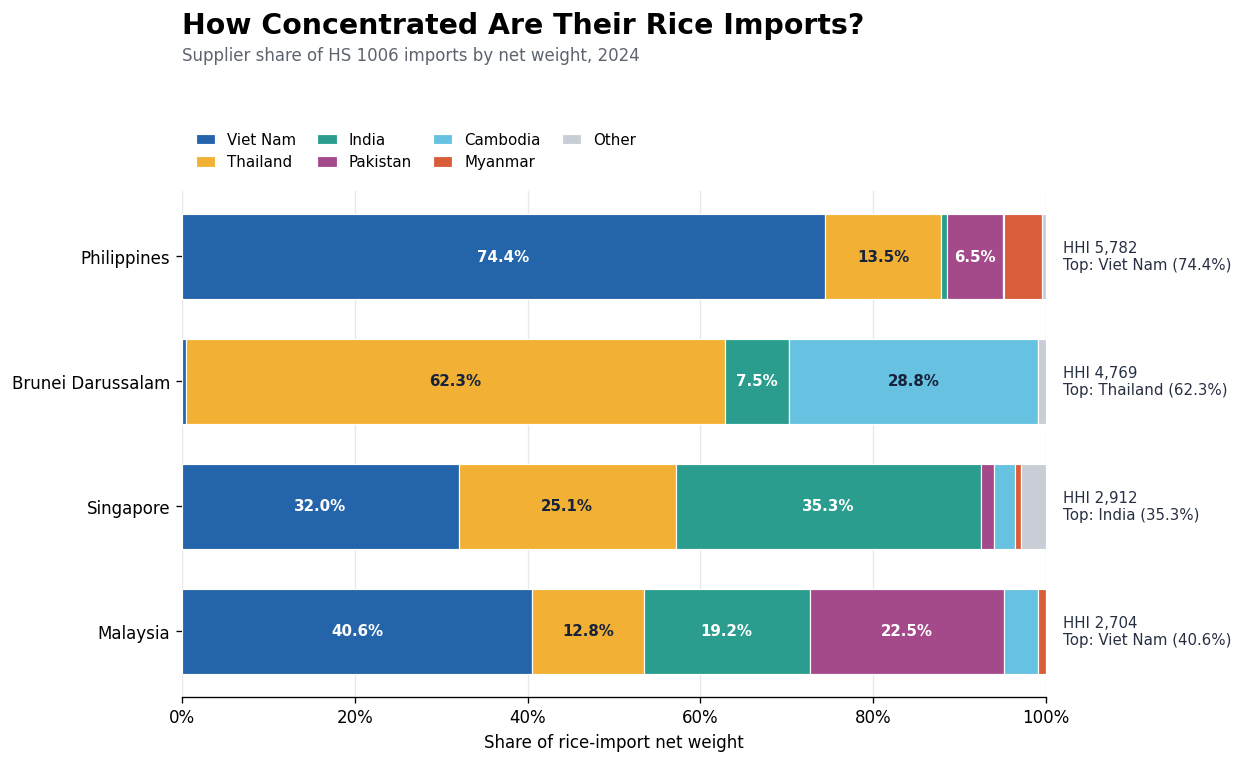

PNG tersimpan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\output_stacked_bar\rice_import_supplier_concentration_2024.png
SVG tersimpan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\output_stacked_bar\rice_import_supplier_concentration_2024.svg


In [11]:
colors = {
    "Viet Nam": "#2364AA",
    "Thailand": "#F2B134",
    "India": "#2A9D8F",
    "Pakistan": "#A44A8B",
    "Cambodia": "#66C2E0",
    "Myanmar": "#D95D39",
    "Other": "#C9CED6",
}
fallback_colors = plt.cm.tab20(np.linspace(0, 1, max(len(extra_suppliers), 1)))
for supplier, color in zip(extra_suppliers, fallback_colors):
    colors[supplier] = color

dark_text_suppliers = {"Thailand", "Cambodia", "Other"}

fig, ax = plt.subplots(figsize=(12, 6.8))
y = np.arange(len(plot_data))
left = np.zeros(len(plot_data))

for supplier in supplier_order:
    values = plot_data[supplier].to_numpy()
    ax.barh(
        y, values, left=left, label=supplier, color=colors[supplier],
        height=0.68, edgecolor="white", linewidth=0.7
    )

    for index, value in enumerate(values):
        if value >= MIN_LABEL_PCT:
            ax.text(
                left[index] + value / 2, index, f"{value:.1f}%",
                ha="center", va="center", fontsize=9,
                color="#17233C" if supplier in dark_text_suppliers else "white",
                fontweight="bold",
            )
    left += values

hhi_indexed = hhi_summary.set_index("reporterDesc")
for index, country in enumerate(plot_data.index):
    hhi_value = hhi_indexed.loc[country, "HHI_10000"]
    top_name = hhi_indexed.loc[country, "top_supplier"]
    top_share = hhi_indexed.loc[country, "top_supplier_share_pct"]
    ax.text(
        1.02, index,
        f"HHI {hhi_value:,.0f}\nTop: {top_name} ({top_share:.1f}%)",
        transform=ax.get_yaxis_transform(), ha="left", va="center",
        fontsize=9, color="#273043",
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_data.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlabel("Share of rice-import net weight", fontsize=10)
ax.set_ylabel("")

fig.suptitle(
    "How Concentrated Are Their Rice Imports?",
    x=0.16, y=0.97, ha="left", fontsize=17, fontweight="bold"
)
fig.text(
    0.16, 0.91, "Supplier share of HS 1006 imports by net weight, 2024",
    ha="left", fontsize=10, color="#5D6470"
)

ax.legend(
    ncol=4, frameon=False, loc="lower left",
    bbox_to_anchor=(0, 1.015), fontsize=9, handlelength=1.3, columnspacing=1.4
)
ax.grid(axis="x", color="#E6E8EC", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

fig.subplots_adjust(right=0.76, top=0.75, left=0.16, bottom=0.13)

png_path = OUTPUT_DIR / "rice_import_supplier_concentration_2024.png"
svg_path = OUTPUT_DIR / "rice_import_supplier_concentration_2024.svg"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
plt.show()

print("PNG tersimpan di:", png_path.resolve())
print("SVG tersimpan di:", svg_path.resolve())

## 12. Mengekspor tabel hasil

Tabel lengkap tetap menyimpan seluruh pemasok asli. Tabel khusus visual berisi kategori yang sudah disederhanakan dengan `Other`.

In [12]:
supplier_share_path = OUTPUT_DIR / "supplier_share_all_partners_2024.csv"
hhi_path = OUTPUT_DIR / "hhi_summary_2024.csv"
quality_path = OUTPUT_DIR / "quality_check_2024.csv"
plot_table_path = OUTPUT_DIR / "stacked_bar_share_table_2024.csv"

supplier_share_table.to_csv(supplier_share_path, index=False)
hhi_summary.to_csv(hhi_path, index=False)
quality_check.to_csv(quality_path, index=False)
plot_data.reset_index().to_csv(plot_table_path, index=False)

print("File hasil:")
for path in [supplier_share_path, hhi_path, quality_path, plot_table_path]:
    print("-", path.resolve())

File hasil:
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\output_stacked_bar\supplier_share_all_partners_2024.csv
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\output_stacked_bar\hhi_summary_2024.csv
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\output_stacked_bar\quality_check_2024.csv
- C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\output_stacked_bar\stacked_bar_share_table_2024.csv


## 13. Ringkasan pembacaan hasil

Berdasarkan data ini, Filipina memiliki konsentrasi pemasok tertinggi. Sekitar 74,4% volume impor berasnya berasal dari Viet Nam. Brunei Darussalam juga terkonsentrasi, terutama pada Thailand dan Cambodia. Singapura dan Malaysia memiliki pembagian pemasok yang lebih beragam dibanding dua negara tersebut, tetapi HHI keduanya masih berada di atas 1.800.

HHI hanya menggambarkan konsentrasi pemasok. Indikator ini belum memasukkan stok domestik, kebijakan ekspor, kontrak dagang, jalur logistik, kualitas beras, atau kemampuan berpindah pemasok.